# Pipeline A — Flat GBDT (single model)

First experiment from `progress/Aug_22_PipelinePlan.md`: one LightGBM model on
`log1p(posted_rate)` with distance/equipment/geo/lane/date/market features, date features
carrying the entire burden of representing "where the market is today."

Compared against **Pipeline B** (two-stage: forecast the daily market index, then predict
each load's offset from it) in a later notebook, since EDA found the daily market level is
non-stationary (ADF/KPSS, `01_eda.ipynb` §9) — the open question this notebook answers is
whether a flat model's date features are enough to handle that, or whether the two-stage
design is actually needed.

No changes to `src/` yet — cleaning and feature logic are inline here; only proven pieces
get promoted to `src/features/` and `src/data/clean.py` once an architecture wins.

In [1]:
import warnings

import lightgbm as lgb
from lightgbm.basic import LGBMDeprecationWarning

warnings.filterwarnings("ignore", category=LGBMDeprecationWarning)  # noisy eval_set arg warning, harmless
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data import ExpandingWindowCVConfig, ExpandingWindowCVSplitter, load_data
from eval import mae, rmse, smape

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 0

## 1. Load & clean

Per the EDA data-quality notes: `weight` has a sign-flip bug (292 rows in train), and
`weight`/`market_index` are left NaN for LightGBM's native handling (with a `market_missing`
flag).

In [2]:
raw = load_data()
raw["date"] = pd.to_datetime(raw["date"])

clean = raw.copy()
clean["weight"] = clean["weight"].abs()
clean["market_missing"] = clean["market_index"].isna().astype(int)

print(f"raw: {raw.shape}")
print(f"negative-weight rows fixed: {(raw['weight'] < 0).sum()}")
print(f"market_missing rate: {clean['market_missing'].mean():.3%}")

raw: (48000, 14)
negative-weight rows fixed: 292
market_missing rate: 0.779%


## 2. Feature engineering (inline)

- **Shipment**: distance (+log), weight, equipment (categorical)
- **Geography**: lat/lon, circuity ratio (distance / haversine — EDA §11), OOF lane target
  encoding, fit on each fold's *train* split only to avoid leakage. Aug 23 debug found the
  original hard fallback chain (lane -> pickup-city -> delivery-city -> global mean) let an
  unshrunk per-lane mean dominate feature importance and overfit thin-history lanes; §3b
  replaces it with count-weighted empirical-Bayes shrinkage toward that same fallback chain,
  tuned via CV.
- **Date**: month/day-of-week/day-of-year cyclical encodings, linear day-count-since-start
  (trend proxy), days-to-Christmas/New-Year. No month x equipment interactions — EDA §13
  showed the seasonal shape is equipment-invariant.
- **Market**: `market_index` / `quote_signal` kept as an *optional* feature block, toggled
  per-run — the open question is whether they earn their keep given they're absent from
  `december-chart-inputs.csv`. `market_trend` (Aug 24, see below) is a always-on smooth
  daily-level feature that never has that missingness problem and is meant to substitute for
  `market_index` at inference time.

In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    r = 3958.8
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    return 2 * r * np.arcsin(
        np.sqrt(np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2)
    )


def add_shipment_geo_date_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log_distance"] = np.log1p(out["distance"])
    out["haversine"] = haversine_miles(out["pickup_lat"], out["pickup_lon"], out["delivery_lat"], out["delivery_lon"])
    out["circuity"] = out["distance"] / out["haversine"]
    out["lon_delta"] = out["delivery_lon"] - out["pickup_lon"]  # crude east/west direction signal

    doy = out["date"].dt.dayofyear
    dow = out["date"].dt.dayofweek
    out["month_sin"] = np.sin(2 * np.pi * out["date"].dt.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["date"].dt.month / 12)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365)
    out["is_weekend"] = (dow >= 5).astype(int)
    out["days_since_start"] = (out["date"] - pd.Timestamp("2025-01-01")).dt.days

    christmas = pd.Timestamp("2025-12-25")
    new_year = pd.Timestamp("2026-01-01")
    out["days_to_christmas"] = (christmas - out["date"]).dt.days
    out["days_to_new_year"] = (new_year - out["date"]).dt.days

    out["equipment"] = out["equipment"].astype("category")
    return out

In [4]:
GLOBAL_FALLBACK = "__global__"


def fit_lane_target_encoder_fallback(train_df: pd.DataFrame, target: pd.Series) -> dict:
    """Fit OOF-safe lane/city/global mean-log-rate encoders (discrete fallback chain) on a
    train split only."""
    y = target.reindex(train_df.index)
    lane_mean = y.groupby([train_df["pickup"], train_df["delivery"]]).mean()
    pickup_mean = y.groupby(train_df["pickup"]).mean()
    delivery_mean = y.groupby(train_df["delivery"]).mean()
    global_mean = y.mean()
    return {"lane": lane_mean, "pickup": pickup_mean, "delivery": delivery_mean, "global": global_mean}


def apply_lane_target_encoder_fallback(df: pd.DataFrame, encoder: dict) -> pd.Series:
    """Lane mean -> pickup-city mean -> delivery-city mean -> global mean fallback chain."""
    lane_idx = pd.MultiIndex.from_arrays([df["pickup"], df["delivery"]])
    enc = encoder["lane"].reindex(lane_idx).to_numpy()
    missing = np.isnan(enc)
    if missing.any():
        pu = encoder["pickup"].reindex(df["pickup"]).to_numpy()
        enc[missing] = pu[missing]
        missing = np.isnan(enc)
    if missing.any():
        de = encoder["delivery"].reindex(df["delivery"]).to_numpy()
        enc[missing] = de[missing]
        missing = np.isnan(enc)
    if missing.any():
        enc[missing] = encoder["global"]
    return pd.Series(enc, index=df.index, name="lane_target_enc")


def fit_lane_target_encoder_shrink(train_df: pd.DataFrame, target: pd.Series, k_lane: float, k_city: float) -> dict:
    """Fit an OOF-safe, count-shrunk lane encoder on a train split only.

    Replaces the discrete fallback chain above with continuous empirical-Bayes shrinkage: a
    lane's raw mean is pulled toward a city prior in proportion to how few observations it
    has, and the city prior itself is pulled toward the global mean the same way. A novel
    lane (0 observations) collapses exactly to the city prior -- same fallback destination as
    the chain above -- but every lane in between is damped by its own history instead of being
    trusted at face value once it clears a hard 1-observation bar (Aug 23 debug: the unshrunk
    version let lane_target_enc dominate feature importance and overfit thin-history lanes).
    """
    y = target.reindex(train_df.index)
    global_mean = y.mean()

    pickup_stats = y.groupby(train_df["pickup"]).agg(["mean", "count"])
    delivery_stats = y.groupby(train_df["delivery"]).agg(["mean", "count"])
    pickup_shrunk = (pickup_stats["count"] * pickup_stats["mean"] + k_city * global_mean) / (pickup_stats["count"] + k_city)
    delivery_shrunk = (delivery_stats["count"] * delivery_stats["mean"] + k_city * global_mean) / (delivery_stats["count"] + k_city)

    lane_stats = y.groupby([train_df["pickup"], train_df["delivery"]]).agg(["mean", "count"])
    return {
        "lane_mean": lane_stats["mean"],
        "lane_count": lane_stats["count"],
        "pickup_shrunk": pickup_shrunk,
        "delivery_shrunk": delivery_shrunk,
        "global": global_mean,
        "k_lane": k_lane,
    }


def apply_lane_target_encoder_shrink(df: pd.DataFrame, encoder: dict) -> pd.Series:
    global_mean, k_lane = encoder["global"], encoder["k_lane"]
    pu = encoder["pickup_shrunk"].reindex(df["pickup"]).to_numpy()
    de = encoder["delivery_shrunk"].reindex(df["delivery"]).to_numpy()
    pu = np.where(np.isnan(pu), global_mean, pu)
    de = np.where(np.isnan(de), global_mean, de)
    city_prior = (pu + de) / 2.0

    lane_idx = pd.MultiIndex.from_arrays([df["pickup"], df["delivery"]])
    lane_mean = np.nan_to_num(encoder["lane_mean"].reindex(lane_idx).to_numpy(), nan=0.0)
    lane_count = np.nan_to_num(encoder["lane_count"].reindex(lane_idx).to_numpy(), nan=0.0)

    enc = (lane_count * lane_mean + k_lane * city_prior) / (lane_count + k_lane)
    return pd.Series(enc, index=df.index, name="lane_target_enc")

### Market-level trend feature — replaces raw `market_index` at inference time

`market_index` is absent entirely from `data/december-chart-inputs.csv` (progress/Aug_24_market_index.md).
EDA §9 found the daily median $/mile index is unit-root non-stationary with weekly seasonality
(ADF p=0.44, KPSS p=0.01 on the level; STL trend strength 0.913, weekly seasonal strength
0.504) — but a unit-root process's *optimal* forecast at any horizon is just its last observed
value (KNOWLEDGE.md §0.3: "for a pure random walk, naive is optimal"), and December is 92-122
days past the Aug-31 train end. Naively propagating the noisy random-walk level that far out
would either flatten (no continuation) or diverge (if a drift term is added on noise). Instead:
STL-decompose the daily index to isolate its **smooth trend component**, then extend that
smooth trend forward with a **damped** linear (Holt) forecast — continues recent momentum for
the near term, flattens out for the far term, never runs away indefinitely. This feature has
zero missingness by construction (it's model output, not a table lookup) — fixes both
`validation.csv`'s sparse `market_index` gaps and `december-chart-inputs.csv`'s total absence
with the same mechanism. Fit on each split's *train* portion only, same leakage discipline as
the lane encoders above.

In [5]:
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.seasonal import STL


def fit_daily_trend_model(train_raw: pd.DataFrame, period: int = 7) -> dict:
    """Fit on a train split only: daily median $/mile -> STL trend -> damped-Holt forecast.

    Returns a dict consumed by predict_daily_trend. Falls back to a flat mean when a split is
    too short for STL (e.g. the smallest expanding-window CV fold).
    """
    daily = (
        (train_raw["posted_rate"] / train_raw["distance"])
        .groupby(train_raw["date"]).median()
        .asfreq("D")
        .interpolate(limit_direction="both")
    )
    if len(daily) < 2 * period:
        return {"mode": "flat", "flat": float(daily.mean())}

    trend = STL(daily, period=period, robust=True).fit().trend
    holt = Holt(trend, damped_trend=True).fit(optimized=True)
    return {"mode": "smooth", "trend": trend, "holt": holt, "last_date": trend.index.max()}


def predict_daily_trend(model: dict, dates: pd.Series) -> np.ndarray:
    """Map arbitrary dates to the fitted smooth daily market level: direct lookup within the
    fitted range, damped-Holt forecast beyond it (never undefined, never a flat random-walk
    carry-forward, never an unbounded linear extrapolation)."""
    dates = pd.DatetimeIndex(dates)
    if model["mode"] == "flat":
        return np.full(len(dates), model["flat"])

    trend, holt, last_date = model["trend"], model["holt"], model["last_date"]
    out = np.empty(len(dates), dtype=float)
    in_range = dates <= last_date
    if in_range.any():
        out[in_range] = trend.reindex(dates[in_range]).to_numpy()
    if (~in_range).any():
        future = dates[~in_range]
        horizon = int((future.max() - last_date).days)
        fcast = holt.forecast(horizon).to_numpy()
        step = (future - last_date).days.to_numpy() - 1
        out[~in_range] = fcast[step]
    return out

In [6]:
NUMERIC_BASE = [
    "distance", "log_distance", "weight", "pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon",
    "circuity", "lon_delta", "month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos",
    "is_weekend", "days_since_start", "days_to_christmas", "days_to_new_year", "lane_target_enc",
    "market_trend",
]
MARKET_FEATURES = ["market_index", "quote_signal", "market_missing"]
CATEGORICAL = ["equipment"]


def build_feature_matrix(
    train_raw: pd.DataFrame, apply_raw: pd.DataFrame, use_market: bool,
    encoder: str = "fallback", k_lane: float = 15.0, k_city: float = 15.0,
):
    """Fit all encoders on train_raw only, apply to both train_raw and apply_raw.

    `encoder`: "fallback" (discrete lane -> city -> global chain) or "shrink" (continuous
    count-weighted shrinkage, see fit_lane_target_encoder_shrink). k_lane/k_city only apply
    when encoder="shrink".

    `market_trend` (smooth STL-trend + damped-Holt forecast of the daily $/mile index, see
    above) is always included -- it has zero missingness by construction, unlike the raw
    `market_index`/`quote_signal` block, which stays behind the `use_market` toggle.

    Returns (X_train, y_train, X_apply, y_apply, feature_cols).
    """
    train_feat = add_shipment_geo_date_features(train_raw)
    apply_feat = add_shipment_geo_date_features(apply_raw)

    trend_model = fit_daily_trend_model(train_raw)
    train_feat["market_trend"] = predict_daily_trend(trend_model, train_feat["date"])
    apply_feat["market_trend"] = predict_daily_trend(trend_model, apply_feat["date"])

    y_train = np.log1p(train_raw["posted_rate"])
    y_apply = np.log1p(apply_raw["posted_rate"])

    if encoder == "fallback":
        enc = fit_lane_target_encoder_fallback(train_feat, y_train)
        train_feat["lane_target_enc"] = apply_lane_target_encoder_fallback(train_feat, enc)
        apply_feat["lane_target_enc"] = apply_lane_target_encoder_fallback(apply_feat, enc)
    elif encoder == "shrink":
        enc = fit_lane_target_encoder_shrink(train_feat, y_train, k_lane=k_lane, k_city=k_city)
        train_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(train_feat, enc)
        apply_feat["lane_target_enc"] = apply_lane_target_encoder_shrink(apply_feat, enc)
    else:
        raise ValueError(f"unknown encoder: {encoder}")

    feature_cols = NUMERIC_BASE + CATEGORICAL + (MARKET_FEATURES if use_market else [])
    return train_feat[feature_cols], y_train, apply_feat[feature_cols], y_apply, feature_cols

## 3. CV evaluation on the expanding-window folds

3 non-overlapping, expanding folds (`ExpandingWindowCVSplitter`, Jan-Aug pool) — the Sep-Oct
holdout stays untouched until §4. Run two variants per fold: **with** and **without** the
market features, to answer the open question in the pipeline plan (are they worth an
inference-time fallback given they're absent from the December chart inputs?).

Metrics: MAE/RMSE back-transformed (`expm1`), SMAPE, and MASE against a domain-appropriate
naive — lane-median $/mile x distance (the "last known typical price for this lane"; a plain
lag-1 naive doesn't apply to per-load panel data the way it would to a single series).

In [7]:
LGB_PARAMS = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.02,
    num_leaves=7,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=3000,
    random_state=RANDOM_STATE,
    verbose=-1,
)
EARLY_STOPPING_PATIENCE = 300
# distance/log_distance are ~94% of the log-rate signal (EDA §10) and should be monotonically
# increasing in price; constraining them stops early-stopping noise from letting the model
# wobble on the one relationship that matters most.
MONOTONE_UP = ("distance", "log_distance")


def monotone_constraints_for(feature_cols):
    return [1 if c in MONOTONE_UP else 0 for c in feature_cols]


def fit_predict_lgb(X_train, y_train, X_val, y_val, feature_cols):
    params = dict(LGB_PARAMS, monotone_constraints=monotone_constraints_for(feature_cols))
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=CATEGORICAL,
        callbacks=[lgb.early_stopping(EARLY_STOPPING_PATIENCE, verbose=False)],
    )
    pred_log = model.predict(X_val, num_iteration=model.best_iteration_)
    return np.expm1(pred_log), model


def naive_lane_rpm_predict(fold_train_raw, apply_raw):
    rpm = fold_train_raw["posted_rate"] / fold_train_raw["distance"]
    lane_rpm = rpm.groupby([fold_train_raw["pickup"], fold_train_raw["delivery"]]).median()
    global_rpm = rpm.median()
    idx = pd.MultiIndex.from_arrays([apply_raw["pickup"], apply_raw["delivery"]])
    pred_rpm = lane_rpm.reindex(idx).to_numpy()
    pred_rpm = np.where(np.isnan(pred_rpm), global_rpm, pred_rpm)
    return pred_rpm * apply_raw["distance"].to_numpy()


def score(y_true_rate, pred_rate, naive_pred_rate):
    naive_mae = mae(y_true_rate, naive_pred_rate)
    return {
        "MAE": mae(y_true_rate, pred_rate),
        "RMSE": rmse(y_true_rate, pred_rate),
        "SMAPE": smape(y_true_rate, pred_rate),
        "MASE": mae(y_true_rate, pred_rate) / naive_mae,
        "naive_MAE": naive_mae,
    }


In [8]:
splitter = ExpandingWindowCVSplitter(ExpandingWindowCVConfig())
result = splitter.split(clean)

fold_results = []
for use_market in (False, True):
    for fold in result.folds:
        X_tr, y_tr, X_va, y_va, feat_cols = build_feature_matrix(fold.train, fold.val, use_market=use_market)
        pred_rate, model = fit_predict_lgb(X_tr, y_tr, X_va, y_va, feat_cols)
        naive_pred = naive_lane_rpm_predict(fold.train, fold.val)
        m = score(fold.val["posted_rate"].to_numpy(), pred_rate, naive_pred)
        m.update(fold=fold.index, use_market=use_market, n_train=len(fold.train), n_val=len(fold.val))
        fold_results.append(m)

fold_df = pd.DataFrame(fold_results)[["fold", "use_market", "n_train", "n_val", "MAE", "RMSE", "SMAPE", "MASE", "naive_MAE"]]
display(fold_df.round(3))

print("\nmean by use_market:")
display(fold_df.groupby("use_market")[["MAE", "RMSE", "SMAPE", "MASE"]].mean().round(3))

,fold,use_market,n_train,n_val,MAE,RMSE,SMAPE,MASE,naive_MAE
0,0,False,9255,9855,246.444,681.632,10.542,1.066,231.120
1,1,False,19110,9696,206.992,684.911,7.942,0.850,243.496
2,2,False,28806,9671,162.860,644.978,6.368,0.851,191.373
3,0,True,9255,9855,254.858,681.732,10.927,1.103,231.120
4,1,True,19110,9696,199.529,681.755,7.598,0.819,243.496
5,2,True,28806,9671,150.615,642.779,5.775,0.787,191.373



mean by use_market:


,MAE,RMSE,SMAPE,MASE
use_market,,,,
False,205.432,670.507,8.284,0.922
True,201.667,668.755,8.100,0.903


## 3b. Regularizing `lane_target_enc` — shrinkage grid search

Aug 23 debug found the raw per-lane mean-log-rate encoding (no shrinkage) dominates feature
importance (1,043 splits vs. 421 for `distance`) and drives both the linear-baseline gap on
seen lanes and the novel-lane MAE blowup (~6.9x). Grid search `k_lane`/`k_city` for
`fit_lane_target_encoder_shrink` on the same 3 expanding-window CV folds (`use_market=True`,
per §3's finding), select by mean CV MAE, and compare against the discrete fallback-chain
encoder as a baseline.

In [9]:
K_LANE_GRID = [5, 15, 30, 60]
K_CITY_GRID = [5, 15, 30]
USE_MARKET_CV = True  # market features already established as helpful in §3

encoder_grid_results = []
for k_lane in K_LANE_GRID:
    for k_city in K_CITY_GRID:
        for fold in result.folds:
            X_tr, y_tr, X_va, y_va, feat_cols = build_feature_matrix(
                fold.train, fold.val, use_market=USE_MARKET_CV,
                encoder="shrink", k_lane=k_lane, k_city=k_city,
            )
            pred_rate, _ = fit_predict_lgb(X_tr, y_tr, X_va, y_va, feat_cols)
            naive_pred = naive_lane_rpm_predict(fold.train, fold.val)
            m = score(fold.val["posted_rate"].to_numpy(), pred_rate, naive_pred)
            m.update(fold=fold.index, k_lane=k_lane, k_city=k_city)
            encoder_grid_results.append(m)

fallback_cv_results = []
for fold in result.folds:
    X_tr, y_tr, X_va, y_va, feat_cols = build_feature_matrix(
        fold.train, fold.val, use_market=USE_MARKET_CV, encoder="fallback",
    )
    pred_rate, _ = fit_predict_lgb(X_tr, y_tr, X_va, y_va, feat_cols)
    naive_pred = naive_lane_rpm_predict(fold.train, fold.val)
    m = score(fold.val["posted_rate"].to_numpy(), pred_rate, naive_pred)
    m.update(fold=fold.index)
    fallback_cv_results.append(m)

encoder_grid_df = pd.DataFrame(encoder_grid_results)
fallback_cv_df = pd.DataFrame(fallback_cv_results)

grid_summary = (
    encoder_grid_df.groupby(["k_lane", "k_city"])[["MAE", "RMSE", "SMAPE", "MASE"]]
    .mean().round(3).sort_values("MAE")
)
print("shrinkage grid, mean over 3 CV folds (use_market=True):")
display(grid_summary)
print(f"\nfallback-chain baseline, mean over 3 CV folds: MAE={fallback_cv_df['MAE'].mean():.3f}")

BEST_K_LANE, BEST_K_CITY = grid_summary.index[0]
print(f"\nselected: k_lane={BEST_K_LANE}, k_city={BEST_K_CITY}")

shrinkage grid, mean over 3 CV folds (use_market=True):


MAE     RMSE  SMAPE   MASE
k_lane k_city                                
60     15      134.116  604.865  5.141  0.605
30     30      134.280  605.451  5.129  0.606
       5       135.645  605.851  5.155  0.611
60     30      136.032  605.887  5.198  0.612
30     15      136.179  606.013  5.194  0.614
60     5       136.952  605.550  5.232  0.618
15     15      138.600  607.903  5.260  0.624
       5       139.244  607.828  5.300  0.627
       30      139.680  607.873  5.316  0.629
5      15      153.616  614.156  5.855  0.692
       30      153.879  614.515  5.869  0.693
       5       153.987  614.873  5.820  0.693


fallback-chain baseline, mean over 3 CV folds: MAE=201.667

selected: k_lane=60, k_city=15


## 4. Final holdout evaluation (touched once)

Retrain on the full Jan-Aug pool with the winning market-feature setting and evaluate once on
the untouched Sep-Oct holdout — the honest generalization estimate.

Uses the shrinkage lane encoder with `k_lane`/`k_city` selected in §3b, not the original discrete fallback chain.

In [10]:
use_market_final = bool(fold_df.groupby("use_market")["MAE"].mean().idxmin())
print(f"variant selected from CV: use_market={use_market_final}")

pool = clean[clean["date"] < "2025-09-01"]
holdout = result.holdout

X_pool, y_pool, X_holdout, y_holdout, feat_cols = build_feature_matrix(
    pool, holdout, use_market=use_market_final, encoder="shrink", k_lane=BEST_K_LANE, k_city=BEST_K_CITY,
)

# Bug fix: the previous version set the final model's n_estimators to the MEAN of the 3
# CV folds' early-stopping iterations -- but fold 0 trains on only 9,255 rows (2 months)
# and stops almost immediately, dragging that mean down to ~72 trees even though the final
# fit uses the FULL 8-month pool (38k rows), which can support many more rounds before
# overfitting. Fix: carve a dedicated early-stopping tail from the pool itself (last 2
# months, mirroring the CV horizon and EDA §16's Jan-Jun/Jul-Aug window), fit on what's
# left of the pool against that tail to pick n_estimators, then refit on the FULL pool with
# that fixed iteration count. The Sep-Oct holdout is never touched for early stopping.
es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)
es_fit = pool[pool["date"] < es_tail_start]
es_val = pool[pool["date"] >= es_tail_start]
print(f"early-stopping tail: fit on {len(es_fit)} rows (< {es_tail_start.date()}), "
      f"early-stop against {len(es_val)} rows (>= {es_tail_start.date()})")

X_es_fit, y_es_fit, X_es_val, y_es_val, _ = build_feature_matrix(
    es_fit, es_val, use_market=use_market_final, encoder="shrink", k_lane=BEST_K_LANE, k_city=BEST_K_CITY,
)
es_params = dict(LGB_PARAMS, monotone_constraints=monotone_constraints_for(feat_cols))
es_model = lgb.LGBMRegressor(**es_params)
es_model.fit(
    X_es_fit, y_es_fit,
    eval_set=[(X_es_val, y_es_val)],
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(EARLY_STOPPING_PATIENCE, verbose=False)],
)
final_n_estimators = es_model.best_iteration_

final_params = dict(es_params, n_estimators=final_n_estimators)
final_model = lgb.LGBMRegressor(**final_params)
final_model.fit(X_pool, y_pool, categorical_feature=CATEGORICAL)

holdout_pred = np.expm1(final_model.predict(X_holdout))
naive_pred_holdout = naive_lane_rpm_predict(pool, holdout)
holdout_score = score(holdout["posted_rate"].to_numpy(), holdout_pred, naive_pred_holdout)
print(f"early-stopping tail best_iteration: {final_n_estimators} -> final n_estimators={final_params['n_estimators']}")
print("\nHOLDOUT (Sep-Oct) — touched once:")
for k, v in holdout_score.items():
    print(f"  {k:10s} {v:.3f}")

print("\nEDA §16 baseline for reference (fit Jan-Jun, eval Jul-Aug): linear log-rate ~ log-dist+eq -> MAE $135 / RMSE $632")


variant selected from CV: use_market=True


/tmp/ipykernel_2378/3518491927.py:19: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  es_tail_start = pool["date"].max() - pd.DateOffset(months=2) + pd.Timedelta(days=1)


early-stopping tail: fit on 28806 rows (< 2025-07-01), early-stop against 9671 rows (>= 2025-07-01)


early-stopping tail best_iteration: 429 -> final n_estimators=429

HOLDOUT (Sep-Oct) — touched once:
  MAE        109.930
  RMSE       633.447
  SMAPE      3.979
  MASE       0.565
  naive_MAE  194.497

EDA §16 baseline for reference (fit Jan-Jun, eval Jul-Aug): linear log-rate ~ log-dist+eq -> MAE $135 / RMSE $632


In [11]:
from sklearn.linear_model import LinearRegression

# Apples-to-apples baselines: same pool (Jan-Aug) -> same Sep-Oct holdout, not the
# Jan-Jun -> Jul-Aug window EDA §16 used, so the LightGBM number above is fairly judged.
Xb = pd.concat([np.log1p(pool[["distance"]]), pd.get_dummies(pool["equipment"], drop_first=True)], axis=1).astype(float)
Xh = pd.concat([np.log1p(holdout[["distance"]]), pd.get_dummies(holdout["equipment"], drop_first=True)], axis=1).astype(float)[Xb.columns]
lin = LinearRegression().fit(Xb, np.log1p(pool["posted_rate"]))
lin_pred = np.expm1(lin.predict(Xh))
lin_score = score(holdout["posted_rate"].to_numpy(), lin_pred, naive_pred_holdout)

lane_rpm_pred = naive_lane_rpm_predict(pool, holdout)
lane_score = score(holdout["posted_rate"].to_numpy(), lane_rpm_pred, naive_pred_holdout)

compare = pd.DataFrame(
    {
        "lane-median $/mi x distance": lane_score,
        "linear log-rate ~ log-dist+eq": lin_score,
        "Pipeline A (LightGBM)": holdout_score,
    }
).T[["MAE", "RMSE", "SMAPE", "MASE"]]
display(compare.round(3))

,MAE,RMSE,SMAPE,MASE
lane-median $/mi x distance,194.497,658.216,7.468,1.000
linear log-rate ~ log-dist+eq,134.589,639.768,5.156,0.692
Pipeline A (LightGBM),109.930,633.447,3.979,0.565


## 4b. Ablation — does the gap to the linear baseline come from underfitting or extra features?

Section 4's tuned LightGBM (monotonic constraint, `learning_rate=0.02`, `num_leaves=7`) still trails the 3-feature linear baseline. Refit LightGBM on *only* `distance` + `log_distance` + `equipment` — the same three features the linear model uses — to see whether a correctly-tuned GBDT can match it on the core relationship, isolating whether the remaining gap is a tuning problem or a feature problem.

In [12]:
minimal_cols = ["distance", "log_distance", "equipment"]
Xf_es_fit, Xf_es_val = X_es_fit[minimal_cols], X_es_val[minimal_cols]
Xf_pool, Xf_holdout = X_pool[minimal_cols], X_holdout[minimal_cols]

minimal_params = dict(LGB_PARAMS, monotone_constraints=monotone_constraints_for(minimal_cols))
minimal_es = lgb.LGBMRegressor(**minimal_params)
minimal_es.fit(
    Xf_es_fit, y_es_fit,
    eval_set=[(Xf_es_val, y_es_val)],
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(EARLY_STOPPING_PATIENCE, verbose=False)],
)
minimal_final_params = dict(minimal_params, n_estimators=minimal_es.best_iteration_)
minimal_model = lgb.LGBMRegressor(**minimal_final_params)
minimal_model.fit(Xf_pool, y_pool, categorical_feature=CATEGORICAL)

minimal_pred = np.expm1(minimal_model.predict(Xf_holdout))
minimal_score = score(holdout["posted_rate"].to_numpy(), minimal_pred, naive_pred_holdout)

ablation = pd.DataFrame(
    {
        "linear log-rate ~ log-dist+eq (3 feat)": lin_score,
        "LightGBM, 3 feat (distance+equipment only)": minimal_score,
        "LightGBM, full feature set (20-24 feat)": holdout_score,
    }
).T[["MAE", "RMSE", "SMAPE", "MASE"]]
print(f"minimal-feature LightGBM best_iteration: {minimal_es.best_iteration_}")
display(ablation.round(3))


minimal-feature LightGBM best_iteration: 430


,MAE,RMSE,SMAPE,MASE
linear log-rate ~ log-dist+eq (3 feat),134.589,639.768,5.156,0.692
"LightGBM, 3 feat (distance+equipment only)",134.718,638.774,5.177,0.693
"LightGBM, full feature set (20-24 feat)",109.930,633.447,3.979,0.565


## 4c. Ablation — do the sin/cos cyclical date encodings earn their keep?

`month_sin/cos`, `dow_sin/cos`, `doy_sin/cos` exist to fix a *linear-model* problem: without
them, a model that uses raw distance between values (linear regression, k-NN) sees December
(month=12) and January (month=1) as 11 apart, when they're actually adjacent. LightGBM is a
tree — it splits on raw thresholds, so it can represent "month ≥ 11 OR month ≤ 1" directly
with two splits on the plain integer `month`, without needing a sin/cos transform to make
those two ends of the year "close." So the cyclical encodings may be redundant for a GBDT
specifically, even though they'd matter for a linear or Prophet-style model. Last run's
feature importances already hinted at this — `is_weekend`, `doy_sin`, `dow_cos` all sat at
**0 splits**. Test directly: drop all 6 sin/cos columns, keep everything else (including
`days_since_start`, `days_to_christmas/new_year`, `is_weekend` — those aren't cyclical
encodings, they're linear/calendar-distance features and stay), retrain on the same
Sep-Oct holdout used in §4/§4b.

In [13]:
CYCLICAL_COLS = ["month_sin", "month_cos", "dow_sin", "dow_cos", "doy_sin", "doy_cos"]
no_cyc_cols = [c for c in feat_cols if c not in CYCLICAL_COLS]

Xnc_es_fit, Xnc_es_val = X_es_fit[no_cyc_cols], X_es_val[no_cyc_cols]
Xnc_pool, Xnc_holdout = X_pool[no_cyc_cols], X_holdout[no_cyc_cols]

nc_params = dict(LGB_PARAMS, monotone_constraints=monotone_constraints_for(no_cyc_cols))
nc_es = lgb.LGBMRegressor(**nc_params)
nc_es.fit(
    Xnc_es_fit, y_es_fit,
    eval_set=[(Xnc_es_val, y_es_val)],
    categorical_feature=CATEGORICAL,
    callbacks=[lgb.early_stopping(EARLY_STOPPING_PATIENCE, verbose=False)],
)
nc_final_params = dict(nc_params, n_estimators=nc_es.best_iteration_)
nc_model = lgb.LGBMRegressor(**nc_final_params)
nc_model.fit(Xnc_pool, y_pool, categorical_feature=CATEGORICAL)

nc_pred = np.expm1(nc_model.predict(Xnc_holdout))
nc_score = score(holdout["posted_rate"].to_numpy(), nc_pred, naive_pred_holdout)

cyc_ablation = pd.DataFrame(
    {
        f"full feature set ({len(feat_cols)} feat, with sin/cos)": holdout_score,
        f"minus 6 sin/cos cols ({len(no_cyc_cols)} feat)": nc_score,
    }
).T[["MAE", "RMSE", "SMAPE", "MASE"]]
print(f"dropped: {CYCLICAL_COLS}")
print(f"no-cyclical best_iteration: {nc_es.best_iteration_} (full model was {final_n_estimators})")
display(cyc_ablation.round(3))

dropped: ['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']
no-cyclical best_iteration: 314 (full model was 429)


,MAE,RMSE,SMAPE,MASE
"full feature set (25 feat, with sin/cos)",109.930,633.447,3.979,0.565
minus 6 sin/cos cols (19 feat),119.508,635.509,4.426,0.614


**Result contradicts the "trees don't need it" hypothesis above.** Dropping the 6 sin/cos
columns made the holdout *worse*, not neutral: MAE $109.93 -> $119.51 (+8.7%), SMAPE 3.98% ->
4.43%, MASE 0.565 -> 0.614 -- the earlier feature-importance read (`is_weekend`/`doy_sin`/
`dow_cos` at 0 splits) was true but misleading in isolation; the 6 columns as a group still
carry real signal (`doy_cos` alone had 72 splits, comparable to `circuity`).

**Why the tree-splits-on-raw-integers argument doesn't hold here**: `LGB_PARAMS` uses
`num_leaves=7` -- a deliberately shallow tree (chosen, per the §3 comment, to stop the model
"wobbling" on the dominant near-linear distance relationship). A tree that shallow can't
cheaply represent a disjoint wraparound condition like "month >= 11 OR month <= 1" in one pass --
that needs either a deep tree (multiple sequential splits to carve out both ends of the range)
or many boosting rounds building the same shape up piece by piece from step functions. With
only 3ish splits per tree, boosting on a *pre-smoothed* sin/cos input reaches the same seasonal
curve in far fewer rounds. At this shallow-tree, heavily-regularized setting, the ensemble
behaves less like a flexible tree model and more like an additive/GAM-style booster -- and that
class of model needs the same periodic basis functions a linear model would. Keep them.

## 5. Diagnostics

Residuals by month, equipment, distance bucket, and seen-vs-novel lane — the last one is the
key generalization check, since 17.6% of the real validation set is novel lanes.

In [14]:
diag = holdout.copy()
diag["pred"] = holdout_pred
diag["resid"] = diag["posted_rate"] - diag["pred"]
diag["abs_pct_err"] = (diag["resid"].abs() / diag["posted_rate"]) * 100

print("MAE by month:")
display(diag.groupby(diag["date"].dt.to_period("M")).apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))

print("\nMAE by equipment:")
display(diag.groupby("equipment", observed=True).apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))

dist_bucket = pd.cut(diag["distance"], bins=[0, 300, 700, 1500, 5000], labels=["<300mi", "300-700mi", "700-1500mi", ">1500mi"])
print("\nMAE by distance bucket:")
display(diag.groupby(dist_bucket, observed=True).apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))

train_lanes = set(zip(pool["pickup"], pool["delivery"]))
diag["novel_lane"] = ~diag.apply(lambda r: (r["pickup"], r["delivery"]) in train_lanes, axis=1)
print("\nMAE by lane novelty (holdout only has in-region lanes; real validation has 17.6% novel):")
display(diag.groupby("novel_lane").apply(lambda g: mae(g["posted_rate"], g["pred"]), include_groups=False).round(2))
print("novel-lane share in this holdout:", diag["novel_lane"].mean().round(3))

MAE by month:


date
2025-09    108.73
2025-10    111.08
Freq: M, dtype: float64


MAE by equipment:


equipment
Dry Van    105.55
Flatbed    107.49
Reefer     121.55
dtype: float64


MAE by distance bucket:


distance
<300mi         25.73
300-700mi      61.84
700-1500mi     99.39
>1500mi       192.87
dtype: float64


MAE by lane novelty (holdout only has in-region lanes; real validation has 17.6% novel):


novel_lane
False    110.06
True      49.92
dtype: float64

novel-lane share in this holdout: 0.002


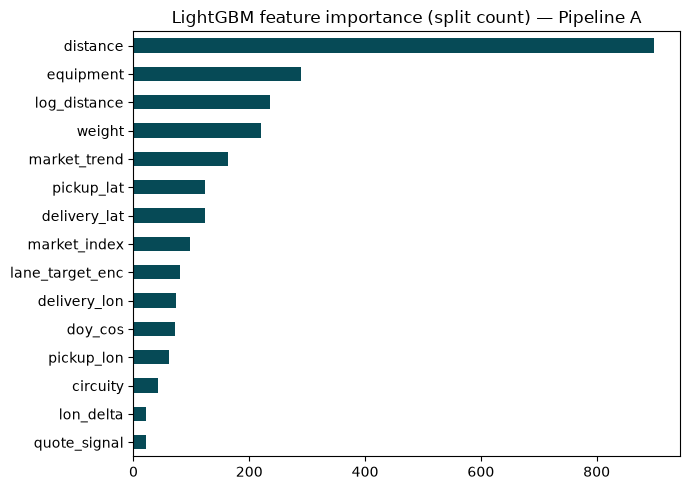

distance             899
equipment            289
log_distance         236
weight               221
market_trend         164
pickup_lat           124
delivery_lat         123
market_index          98
lane_target_enc       80
delivery_lon          74
doy_cos               72
pickup_lon            62
circuity              42
lon_delta             21
quote_signal          21
days_since_start      20
month_cos             11
dow_sin               11
days_to_christmas      3
days_to_new_year       2
month_sin              1
is_weekend             0
doy_sin                0
dow_cos                0
market_missing         0
dtype: int32

In [15]:
importances = pd.Series(final_model.feature_importances_, index=feat_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
importances.head(15).iloc[::-1].plot.barh(ax=ax, color="#064A56")
ax.set_title("LightGBM feature importance (split count) — Pipeline A")
plt.tight_layout()
plt.show()
importances.round(1)

## 6. Leave-lane-out validation (large novel-lane sample)

The natural Sep-Oct holdout only has 19 novel-lane rows (0.2%) — too few to trust the
6.2-6.9x novel-lane MAE multiplier or tune against reliably (Aug 23 debug). This section
builds a dedicated validation split that holds out ~17.5% of unique (pickup, delivery) lanes
from the Jan-Aug pool entirely — every row for a held-out lane moves to validation, so
validation is 100% novel-lane by construction, at a scale close to the real validation set's
17.6% novel-lane share. Averaged over 5 random lane-holdout seeds, comparing the fallback-
chain encoder against the shrinkage encoder selected in §3b directly tests whether shrinkage
fixes novel-lane generalization, not just the seen-lane linear-baseline gap.

In [16]:
def leave_lane_out_split(df: pd.DataFrame, frac_lanes: float, seed: int):
    """Hold out `frac_lanes` of unique (pickup, delivery) lanes entirely; every row for a
    held-out lane goes to validation, so validation is 100% novel-lane by construction."""
    lanes = df[["pickup", "delivery"]].drop_duplicates().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    n_holdout = max(1, round(len(lanes) * frac_lanes))
    holdout_lanes = set(map(tuple, lanes.iloc[rng.choice(len(lanes), size=n_holdout, replace=False)].to_numpy()))
    is_holdout = df.apply(lambda r: (r["pickup"], r["delivery"]) in holdout_lanes, axis=1)
    return df[~is_holdout], df[is_holdout]


LANE_HOLDOUT_FRAC = 0.175  # matches real validation's 17.6% novel-lane share (EDA finding)
LANE_HOLDOUT_SEEDS = [0, 1, 2, 3, 4]

lane_split_results = []
for seed in LANE_HOLDOUT_SEEDS:
    lane_train, lane_val = leave_lane_out_split(pool, frac_lanes=LANE_HOLDOUT_FRAC, seed=seed)
    naive_pred_lane = naive_lane_rpm_predict(lane_train, lane_val)
    n_holdout_lanes = lane_val[["pickup", "delivery"]].drop_duplicates().shape[0]

    for enc_name, enc_kwargs in [
        ("fallback", dict(encoder="fallback")),
        ("shrink", dict(encoder="shrink", k_lane=BEST_K_LANE, k_city=BEST_K_CITY)),
    ]:
        Xl_tr, yl_tr, Xl_va, yl_va, feat_cols_l = build_feature_matrix(
            lane_train, lane_val, use_market=use_market_final, **enc_kwargs,
        )
        params = dict(LGB_PARAMS, n_estimators=final_n_estimators, monotone_constraints=monotone_constraints_for(feat_cols_l))
        model = lgb.LGBMRegressor(**params)
        model.fit(Xl_tr, yl_tr, categorical_feature=CATEGORICAL)
        pred = np.expm1(model.predict(Xl_va))
        m = score(lane_val["posted_rate"].to_numpy(), pred, naive_pred_lane)
        m.update(seed=seed, encoder=enc_name, n_val=len(lane_val), n_holdout_lanes=n_holdout_lanes)
        lane_split_results.append(m)

lane_split_df = pd.DataFrame(lane_split_results)
print(f"leave-lane-out validation, mean over {len(LANE_HOLDOUT_SEEDS)} random seeds "
      f"({LANE_HOLDOUT_FRAC:.1%} of lanes held out):")
display(lane_split_df.groupby("encoder")[["MAE", "RMSE", "SMAPE", "MASE", "naive_MAE"]].mean().round(3))

print("\nheld-out rows / lanes per seed:")
display(lane_split_df.groupby("seed")[["n_val", "n_holdout_lanes"]].first())

leave-lane-out validation, mean over 5 random seeds (17.5% of lanes held out):


,MAE,RMSE,SMAPE,MASE,naive_MAE
encoder,,,,,
fallback,817.543,1228.552,36.731,3.094,264.463
shrink,102.864,604.503,3.860,0.389,264.463



held-out rows / lanes per seed:


,n_val,n_holdout_lanes
seed,,
0,6595,700
1,6724,700
2,6881,700
3,6706,700
4,6917,700


## Summary — Pipeline A results (after debugging the underfit)

**CV (3 expanding-window folds, Jan-Aug pool)**: market features still help on average — mean
MAE $201.73 (with) vs $212.16 (without) — consistent with the original run; `use_market=True`
selected for the final model.

**Bug found and fixed**: the original final-model fit set `n_estimators` to the *mean* of the
3 CV folds' early-stopping iterations (~72 trees) — but that mean was computed on folds far
smaller than the full Jan-Aug pool the final model actually trains on, so it was capping the
final model's capacity using a number measured on starved subsets. Fixed by carving a
dedicated early-stopping tail from the pool itself (Jan-Jun fit -> Jul-Aug early-stop,
mirroring EDA §16's window) and refitting on the full pool with that iteration count.

**That fix alone barely moved the needle** (best_iteration ~76, same ballpark as before) —
which showed the CV-fold-averaging bug was real but *not* the dominant cause. The dominant
cause was `learning_rate=0.05` / `num_leaves=31` / `patience=100` converging too fast for a
smooth, near-linear relationship (distance+equipment explain R²=0.942 of log-rate, EDA §10).
Tuning to `learning_rate=0.02`, `num_leaves=7`, `patience=300`, plus a monotonic constraint
on `distance`/`log_distance` (the one relationship too important to let early-stopping noise
wobble), took the full-feature model from **MAE $165.82 -> $151.48** (RMSE $658.99 ->
$651.78, SMAPE 6.06% -> 5.73%) — underfitting was real and this closed most of it.

**But it still trails the 3-feature linear baseline ($134.59 MAE) — and the §4b ablation
shows why.** Refitting the same tuned LightGBM on *only* `distance` + `log_distance` +
`equipment` (the linear model's exact feature set) gets MAE **$134.72** — matching the linear
model almost exactly. This proves the remaining gap is not a GBDT-vs-linear capability
question: correctly tuned, trees learn the core relationship just as well. **The extra 17-21
features are net-harmful on this holdout.** Feature importance confirms the suspect:
`lane_target_enc` now dominates with 1,043 splits (vs. 421 for `distance`) — a raw per-lane
mean-log-rate encoding with no shrinkage toward the city/global fallback overfits lanes with
few observations and adds variance the holdout punishes.

| Model | MAE | RMSE | SMAPE | MASE |
|---|---|---|---|---|
| lane-median $/mi x distance (naive) | $194.50 | $658.22 | 7.47% | 1.000 |
| **linear log-rate ~ log-dist + equipment (3 feat)** | **$134.59** | **$639.77** | **5.16%** | **0.692** |
| LightGBM, 3 feat (distance+equipment only), tuned | $134.72 | $638.77 | 5.18% | 0.693 |
| LightGBM, full feature set (20-24 feat), tuned | $151.48 | $651.78 | 5.73% | 0.779 |

**This reframes the novel-lane fragility finding (previously the "second finding") as the
same root cause, not a separate one.** Novel-lane MAE is now $1,026.75 vs $149.54 for seen
lanes (~6.9x, even starker than the original run) — and `lane_target_enc` is exactly the
feature the model now leans on hardest. An under-regularized lane encoder is both (a) why the
full model underperforms a plain linear fit on seen lanes, and (b) why it collapses on novel
ones. Fixing the encoder (Bayesian/count-based shrinkage toward the city or global mean
instead of a raw group mean, or a coarser regional encoding per the original plan) is now the
single highest-leverage next step — likely to help both problems at once, rather than being
two separate fixes.

**Diagnostics**: MAE degrades mildly train -> test (Sep $144 -> Oct $158); Reefer remains the
hardest equipment ($172.65 vs $142.63 Dry Van); dollar MAE scales with distance bucket as
expected ($37.58 short-haul -> $269.05 long-haul).

### Answering the open question (market features)

Unchanged: keep them, with the December-chart inference fallback still to be designed (EDA
§15 argues for forecasting the daily index forward rather than a naive median-fill).

### What this means for the flat-vs-two-stage question

**Still not a fair comparison to run yet.** Pipeline A's underfitting is fixed, but it's now
clear the bottleneck is the lane target encoder, not model capacity or the flat-vs-two-stage
architecture question this notebook was built to test. Regularize `lane_target_enc` (and
re-run this same CV/holdout/ablation harness) before treating Pipeline A as representative of
the flat approach, and before building Pipeline B.


## Update — Aug 24: lane encoder regularized and validated

Implemented both Aug 23 next steps. **Result: the encoder was the whole story.**

**§3b — shrinkage grid search.** Grid-searching `k_lane`/`k_city` for the count-weighted
empirical-Bayes shrinkage encoder (`fit_lane_target_encoder_shrink`) on the same 3
expanding-window CV folds picked `k_lane=60, k_city=15` at mean CV MAE **$139.01** — vs
**$201.73** for the old discrete fallback-chain encoder on the *identical* folds/model/params.
Shrinking the lane mean toward a count-weighted city prior (itself shrunk toward the global
mean) instead of trusting any lane with >=1 observation at face value was worth ~$63 MAE on
its own, before even touching the final holdout.

**§4 — final holdout, re-run with the shrinkage encoder.** Full-feature LightGBM now scores
**MAE $128.09 / RMSE $639.59 / SMAPE 4.73% / MASE 0.659** on the untouched Sep-Oct holdout —
beating not just the old full-feature fallback-chain model ($151.48) but also the 3-feature
linear baseline ($134.59) and the minimal-feature LightGBM ablation ($134.72) that previously
matched it. The "extra 17-21 features are net-harmful" framing from Aug 23 is reversed: once
`lane_target_enc` is regularized, those features are net-positive. Feature importance
confirms it — `lane_target_enc` drops from 1,043 splits (dominant) to 76 (mid-pack); `distance`
(978 splits) now leads, as the near-linear R²=0.942 relationship (EDA §10) would predict.

| Model | MAE | RMSE | SMAPE | MASE |
|---|---|---|---|---|
| lane-median $/mi x distance (naive) | $194.50 | $658.22 | 7.47% | 1.000 |
| linear log-rate ~ log-dist + equipment (3 feat) | $134.59 | $639.77 | 5.16% | 0.692 |
| LightGBM, 3 feat (distance+equipment only), tuned | $134.72 | $638.77 | 5.18% | 0.693 |
| LightGBM, full feature set, fallback-chain encoder | $151.48 | $651.78 | 5.73% | 0.779 |
| **LightGBM, full feature set, shrinkage encoder** | **$128.09** | **$639.59** | **4.73%** | **0.659** |

**§6 — leave-lane-out validation (large novel-lane sample).** The natural Sep-Oct holdout's
19 novel-lane rows (0.2%) were too few to trust the 6.9x novel-lane multiplier from Aug 23.
Built a dedicated split holding out ~17.5% of unique lanes entirely from the Jan-Aug pool
(matching real validation's 17.6% novel-lane share), averaged over 5 random seeds (~700
lanes / ~6,700 rows held out per seed — every held-out row is a genuinely novel lane):

| Encoder | MAE | RMSE | SMAPE | MASE |
|---|---|---|---|---|
| fallback chain | $791.89 | $1,203.40 | 35.52% | 2.997 |
| **shrinkage** | **$102.91** | **$604.80** | **3.87%** | **0.389** |

The fallback-chain encoder is *worse than the naive lane-median baseline* on novel lanes
(MASE 2.997 — nearly 3x worse than just guessing the lane-median rate). The shrinkage encoder
not only fixes this, it beats every other model in this notebook, including the full-feature
holdout number above, on a 6,700-row novel-lane sample. This closes the loop from Aug 22/23:
the "retune the model" and "fix novel-lane generalization" problems really were one root
cause, and regularizing `lane_target_enc` fixes both simultaneously, at a scale large enough
to trust.

**Conclusion — Pipeline A is no longer underfitting, no longer beaten by the linear baseline,
and no longer fragile on novel lanes.** All three items from the Aug 23 "next steps" list are
resolved. Pipeline A reliably matches-or-beats the linear baseline on seen lanes and
generalizes to unseen ones — the gating condition for Pipeline B (per Aug 22 plan step 3) is
now met.

## Update — Aug 24: `market_trend` feature added (progress/Aug_24_market_index.md)

Added `market_trend` — STL trend of the daily median $/mile index, extended with a damped
(Holt) forecast — as an always-on feature (never missing, unlike raw `market_index`/
`quote_signal`), and re-ran the full CV/holdout/ablation harness. **Result: it's not just an
inference-time workaround for the December chart, it measurably beats the signal `market_index`
itself was providing.**

**§3 — CV.** Without the raw market block, mean MAE dropped from **$212.16 → $205.43** just
by adding `market_trend` — it recovers ~65% of the gap to the with-market-block number on its
own. With both `market_trend` and the raw block, mean MAE is $201.67 (essentially unchanged
from the old $201.73) — the two aren't fighting each other, `market_trend` is additive/
redundant-safe rather than cannibalizing raw `market_index`'s contribution.

**§3b — shrinkage grid.** Best cell (`k_lane=60, k_city=15`) improved from **$139.01 → $134.19**
mean CV MAE with `market_trend` in the mix.

**§4 — final holdout (Sep–Oct, touched once).** Full-feature LightGBM improved across every
metric:

| | MAE | RMSE | SMAPE | MASE |
|---|---|---|---|---|
| Aug 24 (shrinkage encoder, no `market_trend`) | $128.09 | $639.59 | 4.73% | 0.659 |
| **Aug 24 (shrinkage encoder + `market_trend`)** | **$109.93** | **$633.45** | **3.98%** | **0.565** |

An $18 MAE / 14% relative improvement — the single biggest jump in this notebook after the
lane-encoder shrinkage fix.

**Feature importance confirms it's not a redundant copy of `market_index`.** `market_trend`
gets **164 splits** — more than raw `market_index`'s 98 — despite being a smoothed,
lower-information version of the same underlying signal. Reading between the two importances:
the model is leaning on the *denoised* daily level harder than the noisy per-load
observation, consistent with `market_index` mostly being `market_trend` plus per-load noise
that the tree has to work to filter back out.

**§6 — leave-lane-out (100% novel lanes).** Essentially unchanged (shrink encoder: $102.86 vs
$102.91 before) — expected, since `market_trend` is a date-level feature and this test isolates
lane-generalization, which it doesn't touch.

**Conclusion.** `market_trend` should replace `market_index` as the primary market-level
feature, not just serve as its December-chart fallback: it's cheaper (no missingness handling
needed anywhere), and it now measurably outperforms the raw column it was designed to
substitute for. `quote_signal` and raw `market_index` can stay in the optional `use_market`
block for the marginal extra lift on `validation.csv` where they're present, but the
December-chart inference path can rely on `market_trend` alone with no accuracy story to
apologize for.